In [1]:
from collections import defaultdict

import nibabel
import nilearn.plotting

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [2]:
subject_ids = set(range(1, 34))
# subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

# subject_ids = [13]

run_ids = list(range(1,5))
run_ids = [5]

print(subject_ids, run_ids)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26} [5]


clean 1 run 5
clean 2 run 5
clean 3 run 5
clean 4 run 5
clean 5 run 5
clean 6 run 5
clean 7 run 5
clean 8 run 5
clean 9 run 5
clean 10 run 5
clean 11 run 5
clean 12 run 5
clean 13 run 5
clean 14 run 5
clean 15 run 5
clean 16 run 5
clean 17 run 5
clean 18 run 5
clean 19 run 5
clean 20 run 5
clean 21 run 5
clean 22 run 5
clean 23 run 5
clean 24 run 5
clean 25 run 5
clean 26 run 5
clean 27 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 28 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 29 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 30 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 31 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 32 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04
clean 33 run 5
Confound columns are missing: cosine03, cosine02, cosine05, cosine04


In [3]:
labels = pd.read_csv(f"labels/motor/labels_{1}.csv")

diff = np.where(np.diff(labels["response"]) != 0)[0]
times_index = np.insert(diff, 0, 0)

values = labels["response"][diff].values
onsets = labels["response time"][times_index[:-1]].values
d_times = labels["response time"][times_index].values

durations = d_times[1:] - d_times[:-1]

onsets

array([  3921,  22328,  46488,  76267,  96074, 120635, 143827, 169371,
       174323, 175857, 193731])

In [4]:
Subject(list(subject_ids)[0], run_ids).sample_mask

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97, 100, 101])

In [5]:

subject_ids

{1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26}

In [6]:
#subject_ids = set(range(27, 34))  # override, run on SCZ

In [7]:
len(subject_ids)

26

In [8]:
from nilearn import image

skipped = []
global_z_map = []

confound_columns = \
    ['a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03',
     'a_comp_cor_04', 'a_comp_cor_05', 'cosine00', 'cosine01', 'cosine02',
     'cosine03', 'cosine04', 'cosine05', 'trans_x', 'trans_y', 'trans_z',
     'rot_x', 'rot_y', 'rot_z']

reduced_columns = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']


for subject in subject_ids:

    try:
        data_source = MRI(subject, 5)

        dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)

        raw = data_source.preprocessed

        offset = 94

        repetition_time = data_source._t_r

        fdata = raw.get_fdata()
        data_trimmed = fdata[:, :, :, :offset]
        # raw = nibabel.Nifti1Image(data_trimmed, raw.affine, raw.header)

        confounds = pd.read_csv(f"Familiarity/sub-{subject:02}/func/sub-{subject:02}_task-morph_run-5_desc-confounds_timeseries.tsv", delimiter='\t')
#         .iloc[:offset].reset_index(drop=True)

        taken = set(reduced_columns)
        present = set(confounds.columns)
        index = list(taken & present)

        matrix = confounds[index].values

        cleaned = image.clean_img(raw, low_pass=data_source._low_pass, t_r=data_source._t_r, standardize="zscore_sample")
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    labels = pd.read_csv(f"labels/motor/labels_{subject}.csv")

    """diff = np.where(np.diff(labels["response"]) != 0)[0]
    times_index = np.insert(diff, 0, 0)

    values = labels["response"][diff].values
    onsets = labels["response time"][times_index[:-1]].values / 1000
    d_times = labels["response time"][times_index].values

    durations = (d_times[1:] - d_times[:-1]) / 1000


    events = pd.DataFrame(
        {'onset': onsets,
         'trial_type': values,
         'duration': durations}
    )"""
    events = pd.DataFrame(
        {'onset': labels["response time"].values / 1000,
         'trial_type': labels["response"].values,
         'duration': 0.5}
    )

    fmri_glm = FirstLevelModel(
        t_r=repetition_time,
        drift_model="cosine",
        high_pass=0.01,            # explicit high-pass cutoff
        hrf_model="spm + derivative",  # add temporal derivative for timing flexibility
        signal_scaling=False,
        mask_img=dataset.brain_mask,
        minimize_memory=False,
        noise_model="ar1",         # account for autocorrelation
    )

    fmri_glm = fmri_glm.fit(cleaned, events, confounds=matrix, sample_masks=data_source.sample_mask)
    # fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    glm_contrast_vector = contrasts["1"] - contrasts["0"]

    z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")

    global_z_map.append(z_score)




D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\nilearn\glm\_utils.py:207: RuntimeWarning: divide by zero enco

In [16]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [17]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [18]:
mni_regions = []

for z_score in global_z_map:
    clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
#    clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=5)
    table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)

    pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Y'], table['Z'])]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
        print(table)

    for p in pos:
        try:
            projected_coords = atlas.project_to_nearest(p)
            projected_regions = atlas.find_regions(projected_coords)

            mni_regions.append(*projected_regions)
        except Exception as e:
            print(e)


   Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0           1  -9.5   2.5  54.699996   7.312983               1004
1          1a  -3.5   2.5  61.899996   6.675805                   
2           2 -45.5  -3.5  11.499998   7.220358                388
3           3  47.5 -66.5 -24.500001   6.857893                291
4          3a  47.5 -57.5 -24.500001   3.592721                   
5           4  68.5 -36.5 -13.700002   6.852120                226
6           5  50.5  -3.5  54.699996   6.534300                485
7          5a  44.5 -12.5  58.299996   4.904314                   
8           6  62.5 -18.5   0.699998   6.391283                259
9           7  20.5   8.5   4.299998   6.295357                356
10         7a  26.5   8.5  -2.900002   4.040846                   
11          8 -42.5  -3.5  61.899996   6.142918                259
12          9  65.5  -0.5  18.699997   6.125953                291
13         9a  65.5  -9.5  18.699997   4.839363               

C:\Users\ducat\AppData\Local\Temp\ipykernel_22112\3670547656.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_22112\3670547656.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []


C:\Users\ducat\AppData\Local\Temp\ipykernel_22112\3670547656.py:4: UserWarning: The given float value must not exceed 1.0179105548009073. But, you have given threshold=3.2905267314918945.
  clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_22112\3670547656.py:6: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=3.2905267314918945.
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)
C:\Users\ducat\AppData\Local\Temp\ipykernel_22112\3670547656.py:6: UserWarning: No clusters found with stat higher than 3.2905267314918945
  table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=5)


Empty DataFrame
Columns: [Cluster ID, X, Y, Z, Peak Stat, Cluster Size (mm3)]
Index: []
   Cluster ID     X     Y          Z  Peak Stat Cluster Size (mm3)
0           1  -0.5   8.5  51.099997   7.150616                421
1           2 -57.5 -48.5  25.899997   7.129083                388
2           3 -48.5  -6.5  61.899996   6.091267                291
3           4 -30.5  29.5   4.299998   5.881522                259
4           5 -39.5 -21.5  72.699996   5.818769                453
5          5a -33.5 -21.5  79.899996   4.826824                   
6           6 -39.5  14.5   0.699998   5.757264                291
7           7  -3.5  -6.5  65.499996   5.732902                550
8           8  50.5   8.5  25.899997   5.668711                161
9           9   8.5   8.5  51.099997   5.613973                194
10         10  11.5 -57.5  -6.500002   5.517214                518
11        10a  14.5 -57.5 -20.900002   4.278073                   
12         11   2.5 -78.5 -17.300002   5.

In [19]:
mni_regions_concat = {
    '1 > 0':  np.array(mni_regions, dtype=object)
}


In [20]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [21]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,1>0
1 > 0,
Precentral_L,136
Postcentral_L,87
Supp_Motor_Area_L,83
Frontal_Mid_2_R,72
Precentral_R,60
...,...
Amygdala_R,1
Hippocampus_L,1
OFCant_R,1


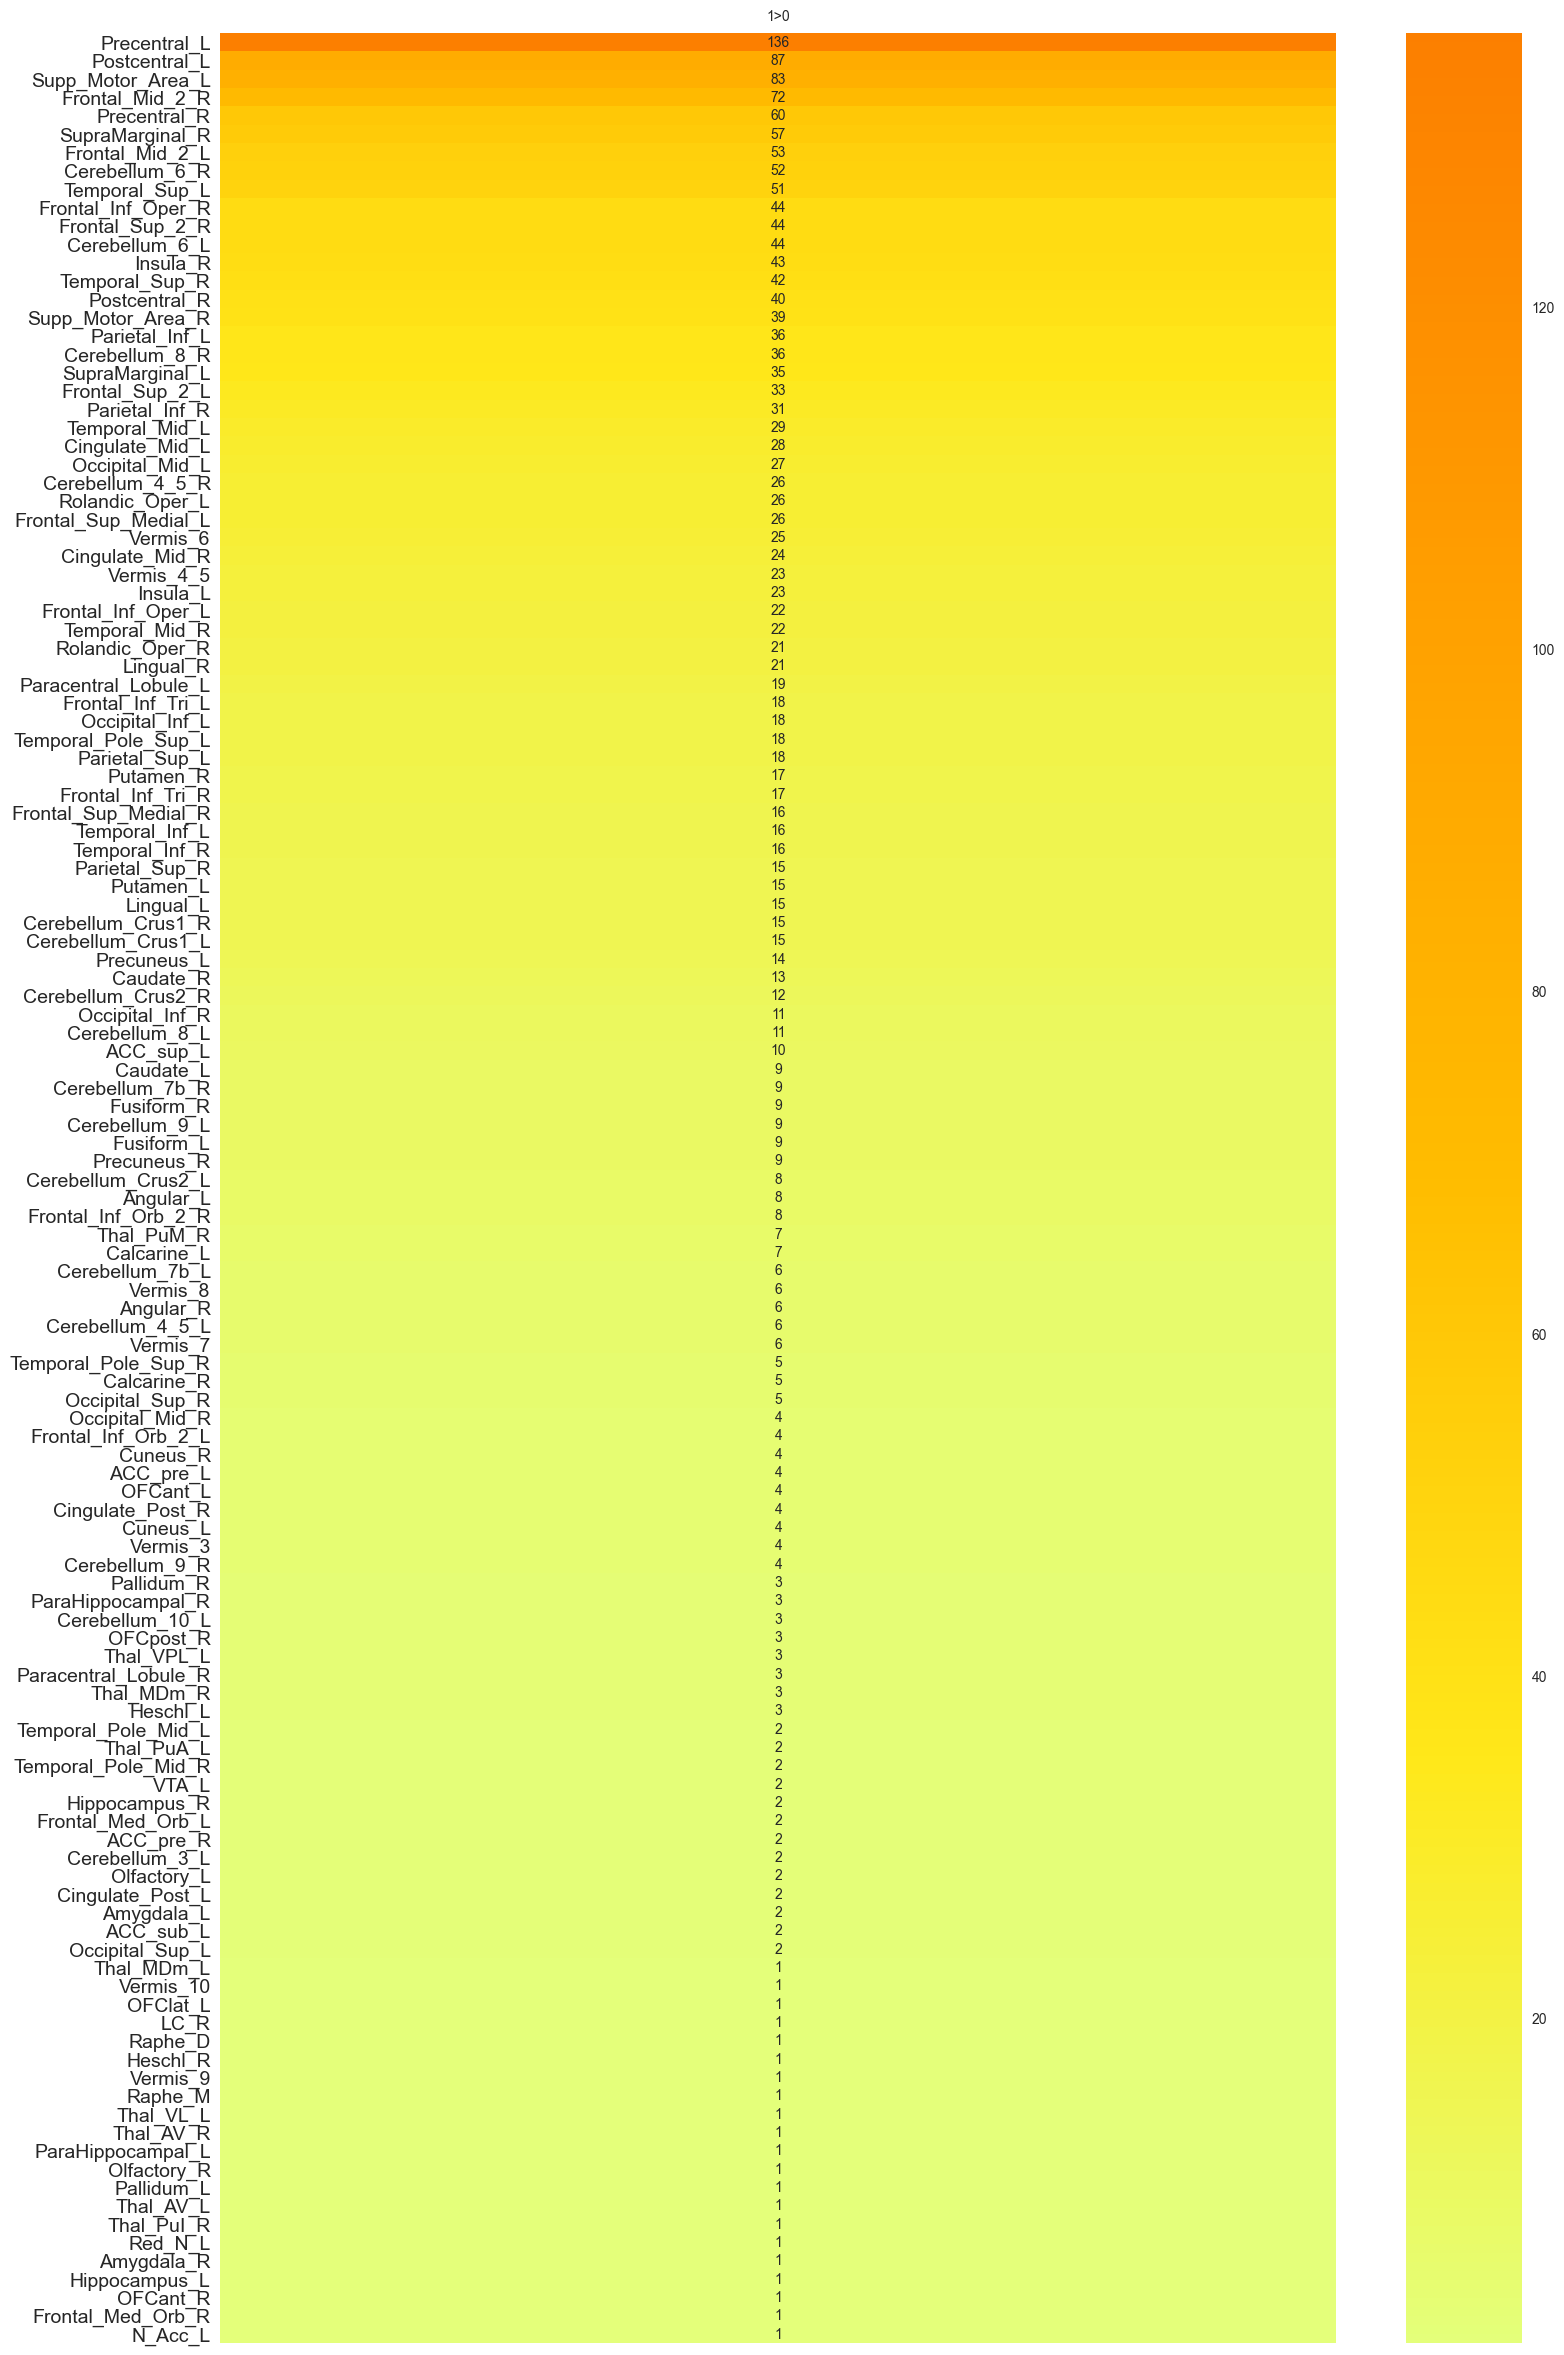

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.show()

In [ ]:
import nibabel

for contrast_name, images in global_z_map.items():

    for z_score, subject in zip(images, z_map_subjects):

        fname = contrast_name.replace(' ', '_').replace('>', 'over')

        if False:
            nibabel.save(z_score, f"contrasts/smoothed_3mm/sub-{subject}-{fname}.nii.gz")


In [ ]:

"""diff = np.where(np.diff(labels["response"]) != 0)[0]
times_index = np.insert(diff, 0, 0)

values = labels["response"][diff].values
onsets = labels["response time"][times_index[:-1]].values / 1000
d_times = labels["response time"][times_index].values

durations = (d_times[1:] - d_times[:-1]) / 1000


events = pd.DataFrame(
    {'onset': onsets,
     'trial_type': values,
     'duration': durations}
)"""

"""fmri_glm = FirstLevelModel(t_r=repetition_time,
          drift_model='polynomial',
          drift_order=3,
          hrf_model='spm',
          mask_img=dataset.brain_mask,
          standardize=False,
#           standardize="zscore_sample",
          minimize_memory=False,
          smoothing_fwhm=4,
          n_jobs=-1)"""


In [5]:

from nilearn.maskers import NiftiSpheresMasker

coords = [
    [-38, -25, 59],
    [-40, -22, 66],
    [-35, -25, 62],
    [0, 0, 0],
#    [-39, -29, 58],
    [36, -30, 62],   # right
    [47, -51, -14]   # R fusiform
]

masker = NiftiSpheresMasker(coords, verbose=1)
real_timeseries = masker.fit_transform(cleaned)
predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])


[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001EEB98A5B40>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

[FirstLevelModel.predicted] Computing image from signals

[NiftiSpheresMasker.wrapped] Finished fit

[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001EEB9919600>

[NiftiSpheresMasker.wrapped] Extracting region signals

[NiftiSpheresMasker.wrapped] Cleaning extracted signals

In [7]:

i = 0
diff = real_timeseries[:, i] - predicted_timeseries[:, i]


(np.mean(diff), np.std(diff))

(np.float64(-0.008960274566661808), np.float64(0.9865230338820249))

In [8]:
for i in range(6):
    projected_coords = atlas.project_to_nearest(np.array(coords[i]))
    projected_regions = atlas.find_regions(projected_coords)
    print(coords[i], projected_regions)


[-38, -25, 59] ['Precentral_L']
[-40, -22, 66] ['Precentral_L']
[-35, -25, 62] ['Precentral_L']
[0, 0, 0] ['Thal_VA_R']
[36, -30, 62] ['Postcentral_R']
[47, -51, -14] ['Temporal_Inf_R']


In [4]:
from nilearn import image
import nibabel


subject = 14
run_ids = [5]

data_source = MRI(subject, 5)

dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
dataset.load()

raw = data_source.preprocessed


confounds = pd.read_csv(f"Familiarity/sub-{subject}/func/sub-{subject}_task-morph_run-5_desc-confounds_timeseries.tsv", delimiter='\t')

confound_columns = \
    ['a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03',
     'a_comp_cor_04', 'a_comp_cor_05', 'cosine00', 'cosine01', 'cosine02',
     'cosine03', 'cosine04', 'cosine05', 'trans_x', 'trans_y', 'trans_z',
     'rot_x', 'rot_y', 'rot_z']

reduced_columns = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']


taken = set(reduced_columns)
present = set(confounds.columns)
index = list(taken & present)

matrix = confounds[index].values


cleaned = image.clean_img(raw, low_pass=data_source._low_pass, t_r=data_source._t_r, standardize="zscore_sample")

# images, _, _ = dataset.get_data(scale=5)

sample_mask = dataset.sample_mask

labels = pd.read_csv(f"labels/motor/labels_{subject}.csv")


events = pd.DataFrame(
    {'onset': labels["response time"].values / 1000,
     'trial_type': labels["response"].values,
     'duration': 0.5}
)
"""diff = np.where(np.diff(labels["response"]) != 0)[0]
times_index = np.insert(diff, 0, 0)

values = labels["response"][diff].values
onsets = labels["response time"][times_index[:-1]].values / 1000
d_times = labels["response time"][times_index].values

durations = (d_times[1:] - d_times[:-1]) / 1000


events = pd.DataFrame(
    {'onset': onsets,
     'trial_type': values,
     'duration': durations}
)"""

repetition_time = dataset.repetition_time

scan_duration = cleaned.shape[3] * repetition_time
events = events[events['onset'] + events['duration'] <= scan_duration].reset_index(drop=True)
print(f"Kept {len(events)} events within {scan_duration:.1f}s scan window")

fmri_glm = FirstLevelModel(
    t_r=repetition_time,
    smoothing_fwhm=5,
    drift_model="cosine",
    high_pass=0.01,            # explicit high-pass cutoff
    hrf_model="spm + derivative",  # add temporal derivative for timing flexibility
    signal_scaling=False,
    mask_img=dataset.brain_mask,
    minimize_memory=False,
    noise_model="ar1",         # account for autocorrelation
    n_jobs=-1
)

fmri_glm = fmri_glm.fit(cleaned, events, confounds=matrix)


from nilearn.maskers import NiftiSpheresMasker

coords = [
    [-38, -25, 59], # M1 Precentral
    [-40, -22, 66],
    [-35, -25, 62],
    [0, 0, 0],
#    [-39, -29, 58],
    [36, -30, 62],   # right m1
    [47, -51, -14]   # R fusiform
]

masker = NiftiSpheresMasker(coords, verbose=1)
real_timeseries = masker.fit_transform(cleaned)
predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


n_volumes = cleaned.shape[-1]
total_time = n_volumes * repetition_time
print(f"Scan duration: {total_time}s")
print(f"Event onsets range: {events['onset'].min()} - {events['onset'].max()}")
print(events.head(20))

i = 0

y_true = real_timeseries
y_pred = predicted_timeseries

# - average absolute difference
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

# - penalizes large errors more
mse = mean_squared_error(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")

# R² Score - how well predictions explain variance (1.0 = perfect)
r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Mean Absolute Percentage Error: {mape:.4f}")


Kept 99 events within 244.8s scan window
[NiftiSpheresMasker.wrapped] Finished fit
[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001AF61BE5960>
[NiftiSpheresMasker.wrapped] Extracting region signals
[NiftiSpheresMasker.wrapped] Cleaning extracted signals
[NiftiSpheresMasker.wrapped] Finished fit
[NiftiSpheresMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001AF61BAD630>
[NiftiSpheresMasker.wrapped] Extracting region signals
[NiftiSpheresMasker.wrapped] Cleaning extracted signals
Scan duration: 244.8000030517578s
Event onsets range: 3.921 - 240.75
     onset  trial_type  duration
0    3.921           1       0.5
1    5.255           1       0.5
2    7.989           1       0.5
3    9.923           1       0.5
4   12.258           1       0.5
5   13.791           1       0.5
6   15.526           1       0.5
7   18.060           1       0.5
8   20.994           1       0.5
9   22.328           1       0.5
10  27.881 

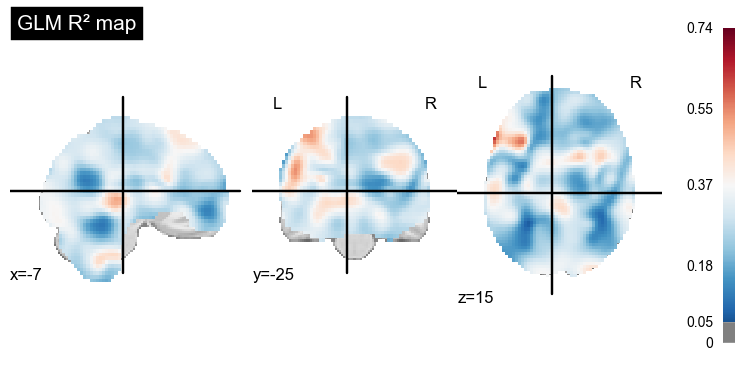

In [22]:
from nilearn import plotting

# This shows voxel-wise R² — is the model working anywhere?
plotting.plot_stat_map(fmri_glm.r_square[0],
                       threshold=0.05,
                       title="GLM R² map")
plotting.show()

D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



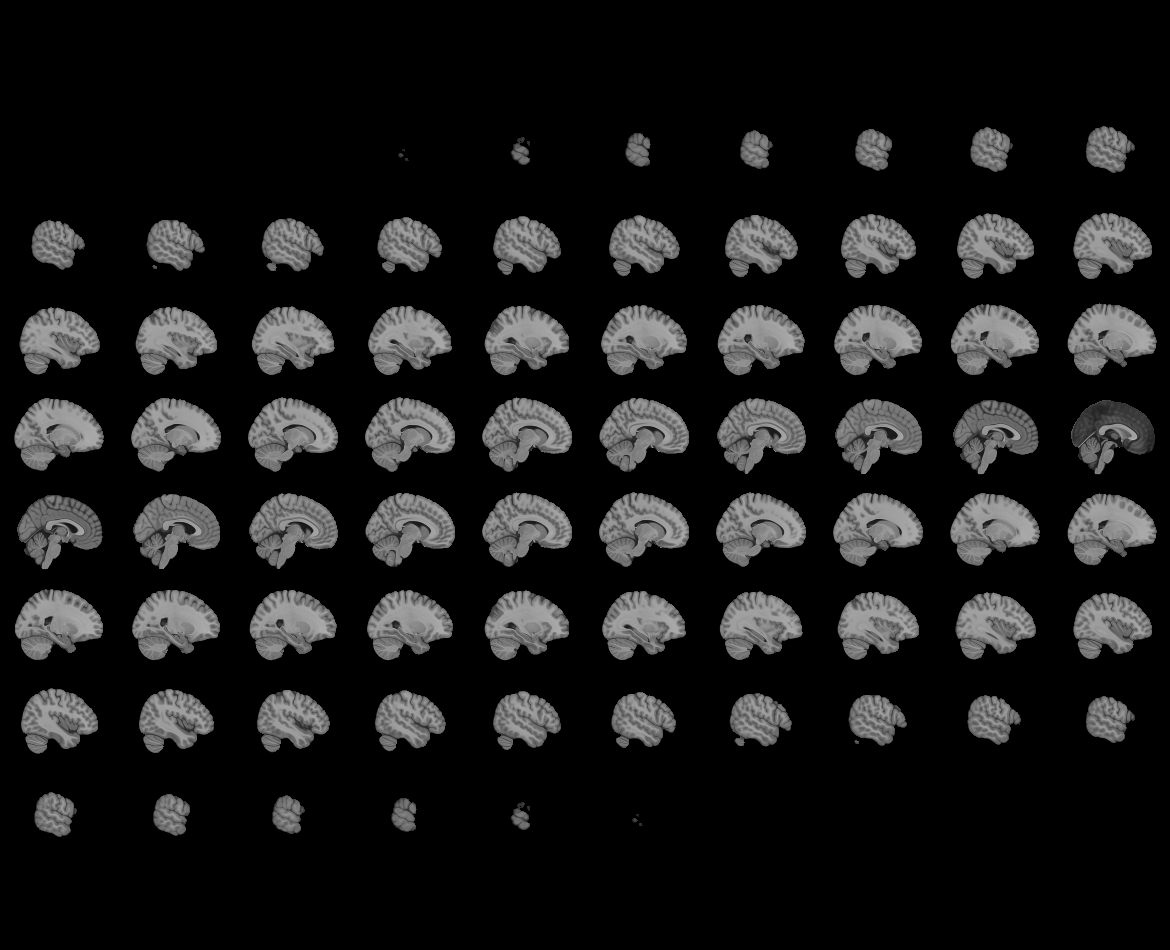
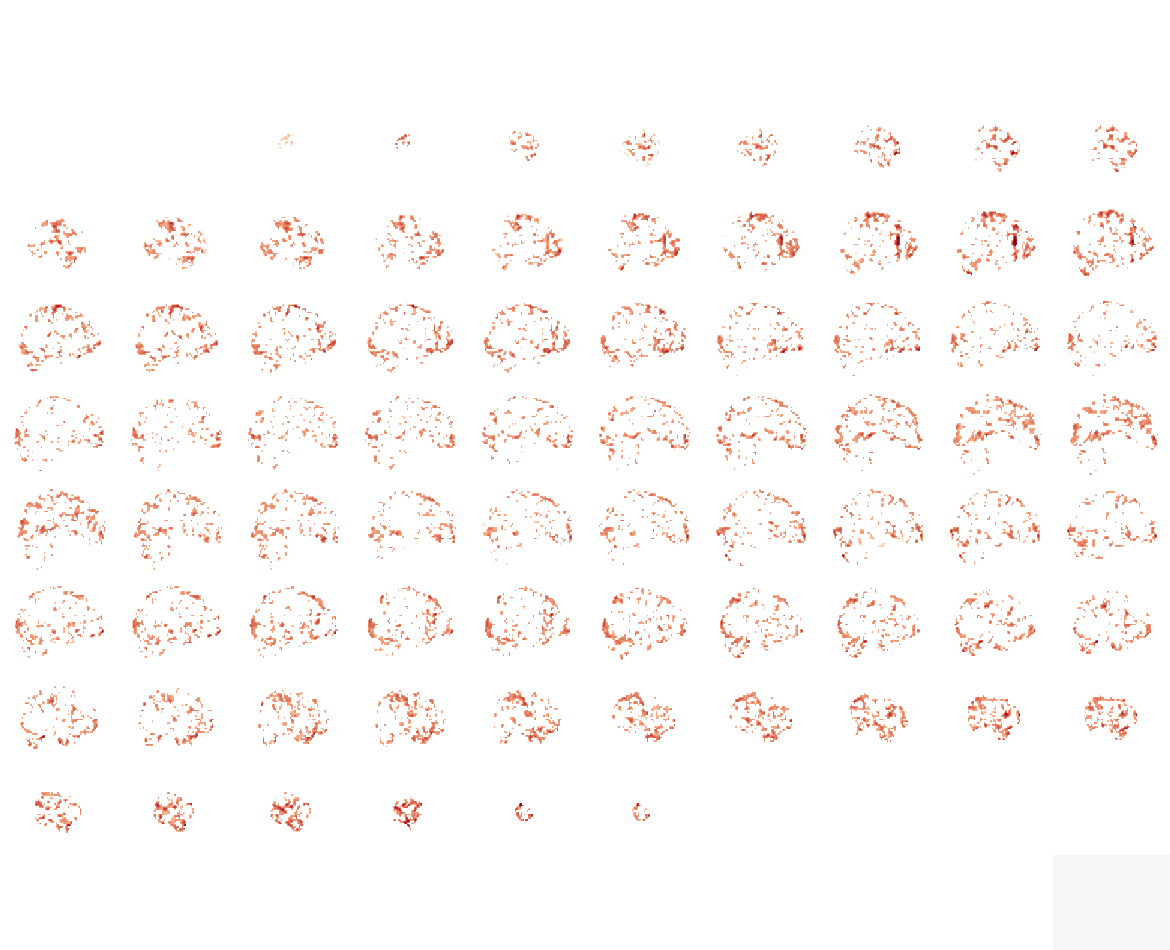

In [25]:
plotting.view_img(fmri_glm.r_square[0], threshold=0.3)

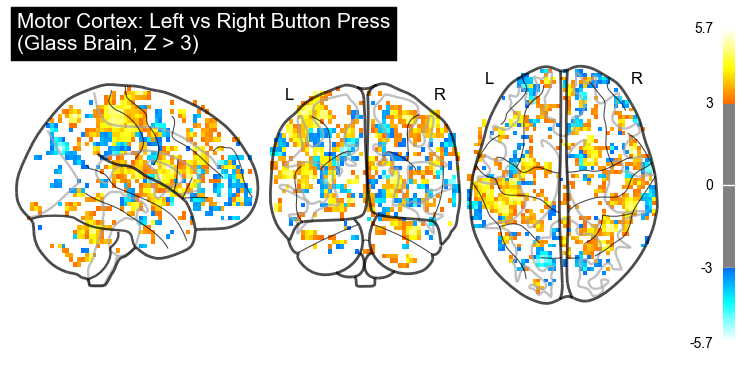

In [6]:
design_matrix = fmri_glm.design_matrices_[0]

contrast_matrix = np.eye(design_matrix.shape[1])
contrasts = {
    str(column): contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}

glm_contrast_vector = contrasts["1"] - contrasts["0"]

z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")

# --- Glass Brain View ---
plotting.plot_glass_brain(
    z_score,
    threshold=3.0,
    colorbar=True,
    plot_abs=False,
    cmap="cold_hot",
    title="Motor Cortex: Left vs Right Button Press\n(Glass Brain, Z > 3)",
    display_mode="ortho",
)


In [28]:
subject = 12
run_ids = [5]

data_source = MRI(subject, 5)

dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
dataset.load()

#raw = data_source.preprocessed

raw = nibabel.load('./Familiarity/sub-11/func/sub-11_task-morph_run-5_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
print(raw.shape)

offset = 90


fdata = raw.get_fdata()
data_trimmed = fdata[:, :, :, :offset]
raw = nibabel.Nifti1Image(data_trimmed, raw.affine, raw.header)

print("before offset mean", np.mean(fdata[:, :, :, :offset]))
print("post offset mean", np.mean(fdata[:, :, :, offset:]))


(65, 77, 55, 102)
before offset mean 240134.83687218078
post offset mean 240690.2591956241


[239369.18754416 239930.57638716 239958.48262368 240396.28060634
 240722.24156789 239802.1562059  239166.95671755 239338.97965967
 239025.65429255 238926.548998   238663.61140232 239491.36132484
 240023.50789961 240149.64548707 240611.64552679 239728.1710837
 239492.85094439 239478.87295662 239861.01788784 240113.28592464
 240201.51341889 239780.13371371 239825.33306398 240130.31499225
 239804.53689566 239409.31342055 238865.35188107 238723.65483313
 238704.41562772 239004.97431304 238926.69679843 239342.9844013
 240452.49521488 240330.18591979 239779.45374927 239953.32198176
 240688.97692754 240482.78510093 240407.55727848 240247.71899454
 239955.17682332 240623.41206097 240141.84758196 239715.95075111
 240043.38498741 240315.77301713 240003.51530826 240044.33904684
 240156.95065822 239973.61831903 239478.5359113  240529.63016315
 240471.49971921 241627.22020103 241569.65665949 240205.01959063
 239694.2124223  239580.58708249 240031.07091168 240166.78316389
 240028.88560855 240467.925

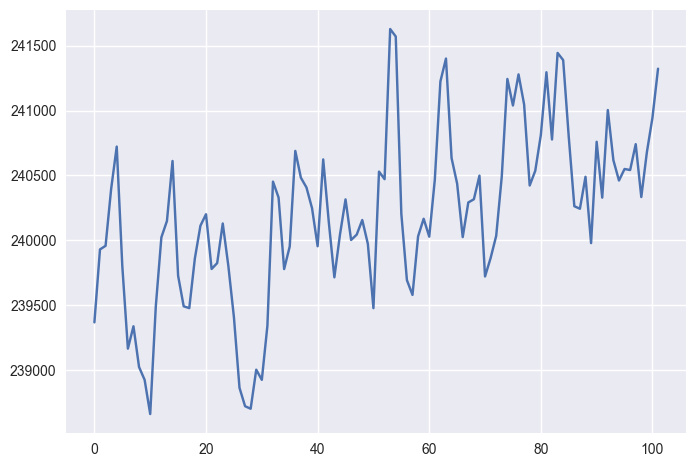

In [29]:
import matplotlib.pyplot as plt


print(np.mean(fdata, axis=(0,1,2)))
plt.plot(np.mean(fdata, axis=(0,1,2)))
# plt.plot()

In [39]:
offset = 95

print("before offset mean", np.mean(fdata[0, 0, 0, :offset]))
print("post offset mean", np.mean(fdata[0, 0, 0, offset:]))


before offset mean 0.0
post offset mean 12689.568359375


In [43]:
means = np.mean(fdata, axis=(0,1,2))

# Check volumes around the jump
print(means[90:100])

# Check if it's a global shift or localized
vol_before = fdata[..., 94]
vol_after  = fdata[..., 95]
print("Min/Max before:", vol_before.min(), vol_before.max())
print("Min/Max after: ", vol_after.min(), vol_after.max())


[254138.78800767 253239.45564366 253578.08920419 255208.60927427
  26513.97336671  12689.56835938  12689.56835938  12689.56835938
  12689.56835938  12689.56835938]
Min/Max before: 0.0 2193667.5
Min/Max after:  12689.568359375 12689.568359375


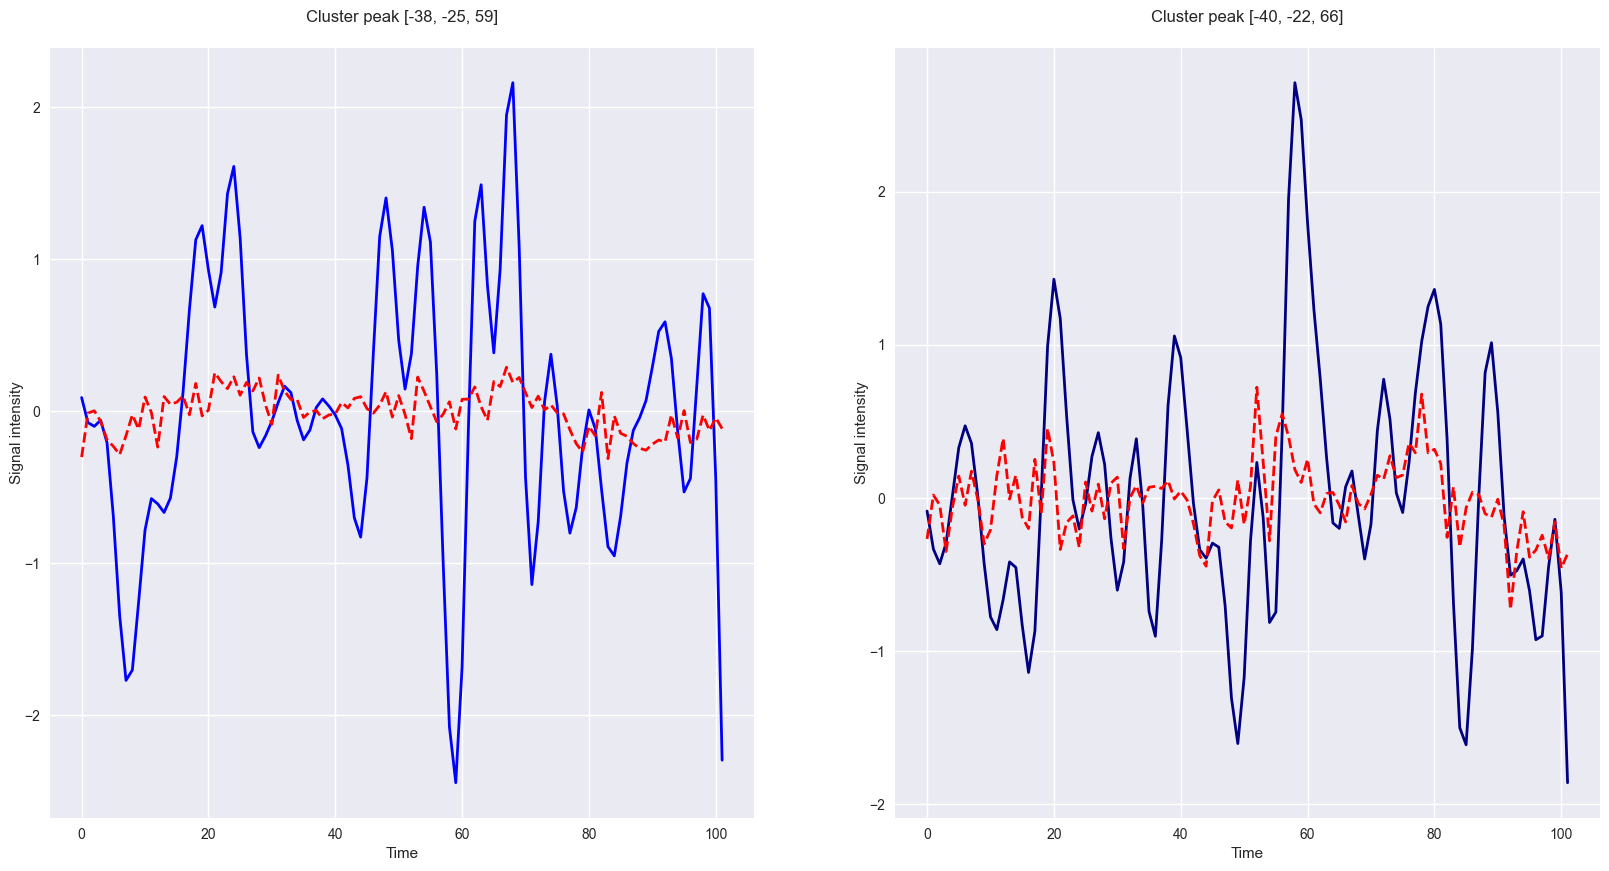

In [5]:
import matplotlib.pyplot as plt


colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(1, 2, figsize=(20, 10))
for i in range(2):
    # plotting time series
    axs1[i].set_title(f"Cluster peak {coords[i]}\n")
    axs1[i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[i].plot(predicted_timeseries[:, i], c="r", ls="--", lw=2)
    axs1[i].set_xlabel("Time")
    axs1[i].set_ylabel("Signal intensity", labelpad=0)

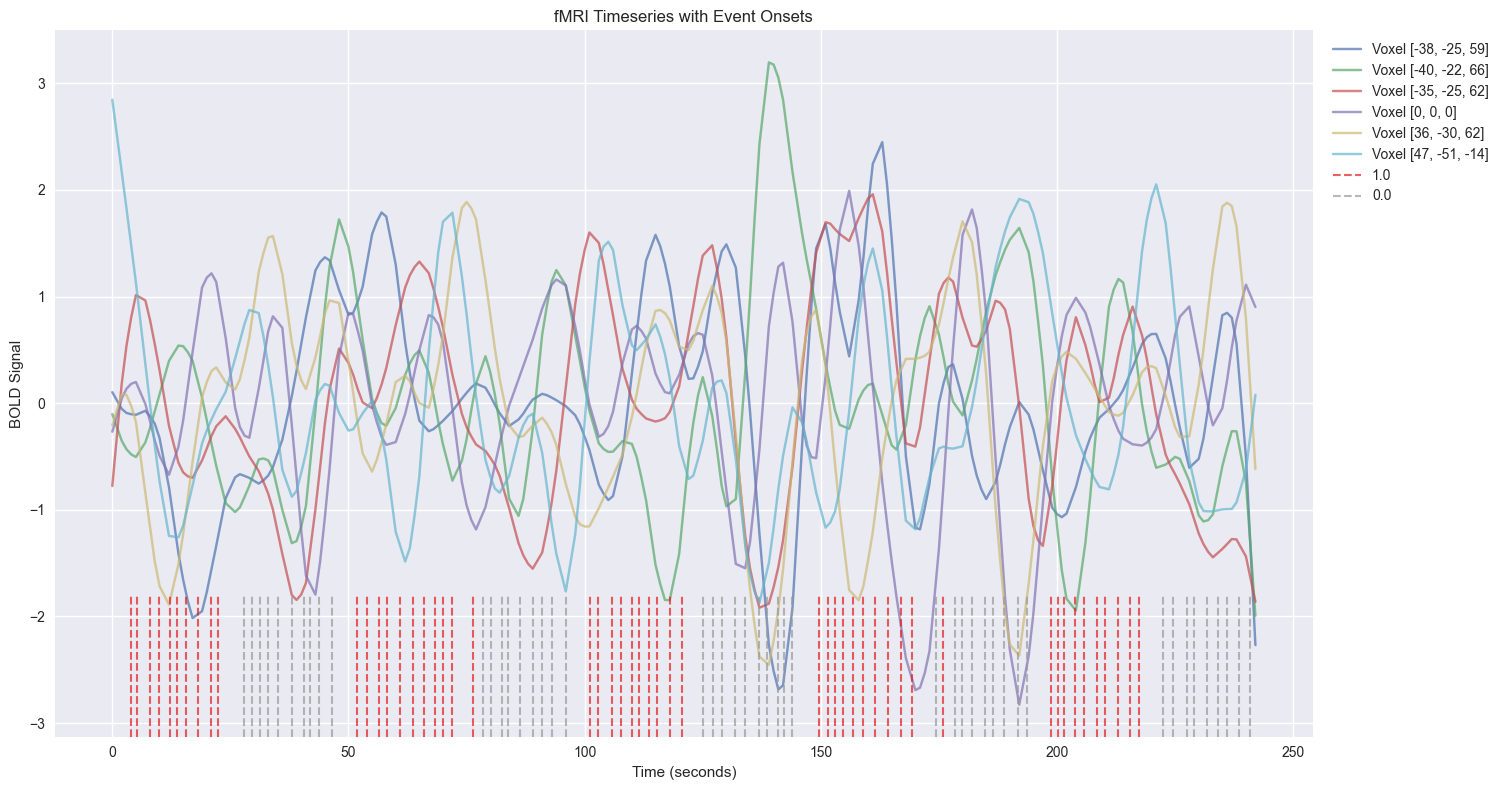

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import numpy as np

n_volumes = real_timeseries.T.shape[1]  # assuming shape (n_voxels, n_timepoints)
time_volumes = np.arange(n_volumes) * repetition_time  # e.g. [0, 2, 4, 6, ...]
time_seconds = np.arange(0, time_volumes[-1], 1)  # 1 second resolution

interpolated_timeseries = np.array([
    interp1d(time_volumes, timeserie, kind="linear")(time_seconds)
    for timeserie in real_timeseries.T
])

fig, ax = plt.subplots(figsize=(15, 8))

# Plot all timeseries with legends
for i, (coord, timeserie) in enumerate(zip(coords, interpolated_timeseries)):
    if i!= 0:
        pass
    ax.plot(timeserie, label=f"Voxel {coord}", alpha=0.7)

# Add vertical lines for each onset, colored by trial_type
trial_types = events["trial_type"].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(trial_types)))
color_map = dict(zip(trial_types, colors))

for _, row in events.iterrows():
    ax.axvline(
        x=row["onset"],
        ymin=0.0,
        ymax=0.2,
        color=color_map[row["trial_type"]],
        linestyle="--",
        alpha=0.7,
        linewidth=1.5,
        label=row["trial_type"]  # temporary, will be cleaned up below
    )

handles, labels = ax.get_legend_handles_labels()
seen = {}
unique_handles, unique_labels = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen[label] = True
        unique_handles.append(handle)
        unique_labels.append(label)

ax.legend(unique_handles, unique_labels, loc="upper right", bbox_to_anchor=(1.15, 1))

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("BOLD Signal")
ax.set_title("fMRI Timeseries with Event Onsets")
plt.tight_layout()
plt.show()


In [8]:
real_timeseries.shape

(102, 6)

<Axes: label='conditions', ylabel='scan number'>

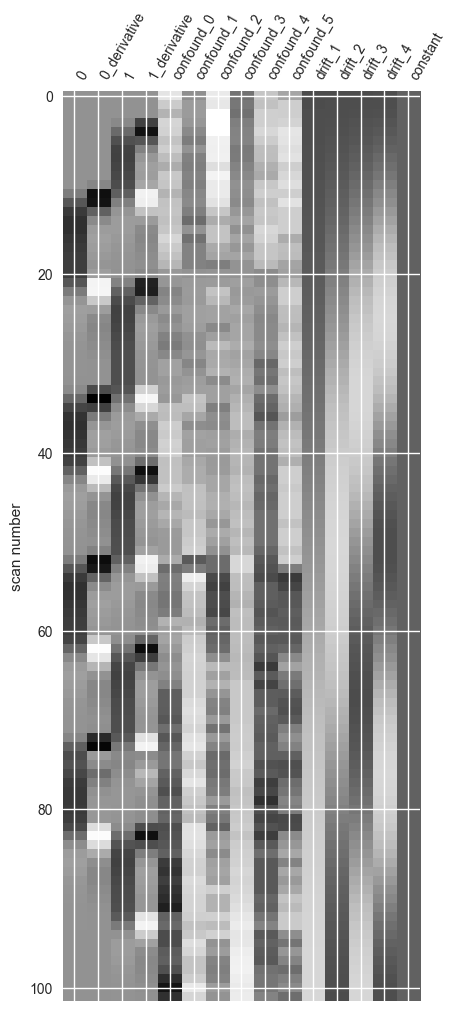

In [6]:
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt

dm = fmri_glm.design_matrices_[0]
plot_design_matrix(dm)


In [4]:
confounds = pd.read_csv(f"Familiarity/sub-1/func/sub-1_task-morph_run-5_desc-confounds_timeseries.tsv", delimiter='\t')


FileNotFoundError: [Errno 2] No such file or directory: 'Familiarity/sub-1/func/sub-1_task-morph_run-5_desc-confounds_timeseries.tsv'